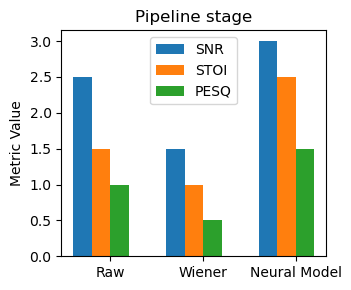

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data to resemble the uploaded histogram
models = ['SNR', 'STOI', 'PESQ']
stages = ['Raw', 'Wiener', 'Neural Model']
errors = np.array([
    [2.5, 1.5, 3.0],  # GPT-3
    [1.5, 1.0, 2.5],  # GPT-4
    [1.0, 0.5, 1.5],  # Code Llama 7B
])

x = np.arange(len(stages))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(3.6, 3))
rects1 = ax.bar(x - 3*width/2, errors[0], width, label=models[0])
rects2 = ax.bar(x - width/2, errors[1], width, label=models[1])
rects3 = ax.bar(x + width/2, errors[2], width, label=models[2])

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Metric Value')
ax.set_title('Pipeline stage')
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.legend()

fig.tight_layout()
plt.savefig('histogram.pdf', dpi=300)
plt.show()

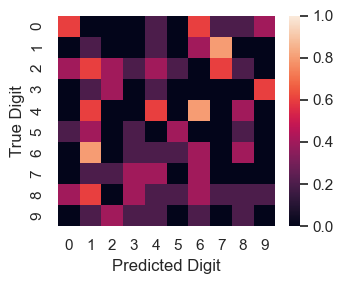

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

# Assuming you have the true labels and predicted labels
# true_labels = [...]
# predicted_labels = [...]
true_labels = np.random.randint(0, 10, 100)  # Replace with actual true labels
predicted_labels = np.random.randint(0, 10, 100)  # Replace with actual predicted labels

# Generate the confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plotting
plt.figure(figsize=(3.6, 3))
sns.set(font_scale=1)  # for label size
sns.heatmap(cm/(5), annot=False, annot_kws={"size": 8}, fmt='d', 
            # set cbar to [0, 1]
            vmin=0, vmax=1,
)
# remove cbar
plt.ylabel('True Digit')
plt.xlabel('Predicted Digit')
# plt.title('Confusion Matrix for AudioMNIST')
plt.tight_layout()
plt.savefig('confusion_matrix.pdf', dpi=300)
plt.show()


# Set variables

In [1]:
GROUND_TRUTH_ROOT = "../vctk/"
SENSOR_ROOT = "../MICEMOUSE/gen/csv"
seed = 42

## Import Needed Libraries

In [ ]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torchaudio
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.signal import *
import os
import torchinfo
import torchvision.transforms

## Import our own backend

In [ ]:
import core.nn.VCTK
from core.signal.preprocess import *
from core.nn.utils import normalize, denormalize, mapToBounds, apply_wiener
import whisper

## Set seed and logging level

In [5]:
import logging
# fix seed for reproducibility
np.random.seed(seed)
torch.manual_seed(seed)
logging.basicConfig(level=logging.INFO)

## Initialize the dataloaders

In [6]:
Fs = 16000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
groundTruthConfig = {
    "root": GROUND_TRUTH_ROOT,
    "download": False,
}
sensorConfig = {
    "root": SENSOR_ROOT,
    "Fs": Fs,
    "device": device,
    "resampleMethod": 'sinc'
}

paired_ds = core.nn.VCTK.PairedAudioDataset(groundTruthConfig, sensorConfig)
filtered_paired_ds = core.nn.VCTK.removeOutliers(paired_ds)
train_loader, test_loader, dev_loader = core.nn.VCTK.getAudioLoaders(filtered_paired_ds, device = device, batch_size=32)

INFO:root:Initializing PairedAudioDataset...


Removed 1387 outliers 3.16% of the dataset
Remaining 43873 samples
Train: 1129 batches = 36128 samples
Test: 166 batches = 5312 samples
Dev: 34 batches = 1088 samples


## Load in the Noise data and build the Wiener Filter

In [8]:
from math import ceil
_, Xnoise, Ynoise = processFromFile("vctk\\gen\\noise\\noise_2023-11-03_21-00-40.csv", method='sinc')
# Pad to closest 16000
Fs = 16000
noise = F.pad((Xnoise+Ynoise)/2, (0, ceil((Xnoise.shape[0] / (5 * Fs)))*(5 * Fs) - Xnoise.shape[0]), "constant", 0)
noise = noise.reshape(-1, 5 * Fs)

In [9]:
# compute FFT in dev set
Data_PSD = []
Noisy_PSD = []
for Xorig, Yorig in tqdm(dev_loader):
    # Get FFTs and aggregate
    Yorig = torch.fft.rfft(Yorig.squeeze().reshape(-1, 5 * Fs).to(device), dim = -1)
    Xorig = torch.fft.rfft(Xorig.squeeze().reshape(-1, 2, 5 * Fs).to(device), dim = -1)
    Data_PSD.append(Yorig)
    Noisy_PSD.append(Xorig)
# Compute average PSD
avgData_PSD = torch.cat(Data_PSD, dim=0).abs().mean(dim=0).cpu()
avgNoisy_PSD = torch.cat(Noisy_PSD, dim=0).abs().mean(dim=0).cpu().mean(dim=0)
# Compute FFT
noiseFFT = torch.fft.rfft(noise, dim=1)
noiseFFT = torch.abs(noiseFFT)
noiseFFT = noiseFFT.mean(dim=0)
H = avgData_PSD / (avgData_PSD + noiseFFT)
plt.plot(H.abs())

100%|██████████| 34/34 [00:09<00:00,  3.74it/s]


## Prepare the transforms to and from the spectrogram domain

In [10]:
tforms = core.nn.utils.buildTransforms(device = device, 
                                        Fs = Fs, 
                                        n_fft = 800, 
                                        win_length = 800,
                                        hop_length = 160,
                                        n_mels = 80,
                                        f_max_mouse = 8000,
                                        f_max_full = 8000,
                                        )
specFn, inverseSpecFn, melFilterMouse, melFilter, inverseMelFn = tforms

toMelDB = lambda batch: core.nn.utils.toMelDB(batch, specFn=specFn, mousemelfilters=melFilterMouse, fullmelfilter=melFilter)

### Plot the spectrum of the sensor data, ground truth, and post-Wiener Filter sensor data

In [ ]:
postFiltering = H.abs() * avgNoisy_PSD.abs()
# fft bin to frequency
X = torch.fft.rfftfreq(80000, 1/16000)

# build a dataframe with 4 columns: frequency, avgNoisy, avgData_PSD, postFiltering
df = pd.DataFrame()
df['frequency'] = X
df['avgNoisy'] = avgNoisy_PSD
df['avgData'] = avgData_PSD
df['postFiltering'] = postFiltering
# save the dataframe
df.to_csv('dataDist.csv', index=False)
plt.plot(postFiltering)
plt.plot(avgData_PSD)

In [20]:
# # The following code is used to compute the min and max values of the spectrograms, we hardcode them here for convenience

# mnmn = torch.inf
# mxmx = -torch.inf
# for Mwav, Wwav in dev_loader:
#     MwavFilt = apply_wiener(Mwav, smoothH.to(device))
#     Mnorm, Wnorm = normalize((MwavFilt, Wwav))
#     Mspec, Wspec, _, _ = toMelDB((Mnorm, Wnorm))
#     Mnofiltspec, _, _, _ = toMelDB((Mwav, Wnorm))
#     mnmn = min(mnmn, Mnofiltspec.min(), Mspec.min(), Wspec.min())
#     mxmx = max(mxmx, Mnofiltspec.max(), Mspec.max(), Wspec.max())
mnmn, mxmx = 0, 2.7663

In [22]:
Mwav, Wwav = next(iter(dev_loader))
MwavFilt = apply_wiener(Mwav, H.to(device))
Mnorm, Wnorm = normalize((MwavFilt, Wwav))
Mspec, Wspec, _, _ = toMelDB((Mnorm, Wnorm))
Mspec, Wspec = core.nn.utils.mapToBounds((Mspec, Wspec), mnmn, mxmx)
Mnofiltspec, _, _, _ = toMelDB((Mwav, Wnorm))
Mnofiltspec, _ = core.nn.utils.mapToBounds((Mnofiltspec, Wspec), mnmn, mxmx)
Wspec = Wspec.to(device)
Mspec = Mspec.to(device)
print(Wspec.shape)
print(Mspec.shape)
fig, ax = plt.subplots(1, 3)
i = 0
ax[0].imshow(Wspec[i, :, :].cpu(), aspect="auto", origin="lower", vmin=-1, vmax=1)
ax[1].imshow(Mnofiltspec[i, :, :].cpu(), aspect="auto", origin="lower", vmin=-1, vmax=1)
ax[2].imshow(Mspec[i, :, :].cpu(), aspect="auto", origin="lower", vmin=-1, vmax=1)
plt.show()

### Load in the Whisper model (encoder only)

In [24]:
perceptualEmbedding = whisper.load_model("tiny").encoder.to(device)
perceptualEmbedding.eval()
for p in perceptualEmbedding.parameters():
    p.requires_grad = False

### Define the filtering NN

In [26]:
from core.nn.whisperPrimitives import *
device = 'cuda' if torch.cuda.is_available() else 'cpu'
embed_d = 384
n_head = 6
n_layer = 4
k_size = 15
padding = k_size // 2
n_mels = 80
model = nn.Sequential(
    nn.Conv1d(n_mels * 2, embed_d, k_size, padding=padding),
    nn.GELU(),
    TransformerChain(n_ctx=501, n_state=embed_d, n_head = n_head, n_layer=n_layer),
    nn.GELU(),
    nn.Conv1d(embed_d, n_mels * 4, k_size, padding=padding),
    nn.GELU(),
    nn.Conv1d(n_mels * 4, n_mels, k_size, padding=padding),
).to(device)

## Define Loss Functions, Optimizer, and Scheduler

In [27]:
def frobenius_norm(X):
    return torch.sqrt(torch.sum(X ** 2))

def spectral_convergence(X, Y):
    return frobenius_norm(X - Y) / frobenius_norm(Y)

lr = 1e-3
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.707)

l1_loss = nn.L1Loss()
l2_loss = nn.MSELoss()
huber_loss = nn.HuberLoss()
perceptual_loss = lambda x, y: l2_loss(perceptualEmbedding(x), perceptualEmbedding(y))
pad_fn = lambda x, y: (F.pad(x, (0, 3000 - x.shape[-1])), F.pad(y, (0, 3000 - y.shape[-1])))

# Uncomment the losses you want to use, Huber loss is the most stable
loss_fn = lambda x, y: (
    # spectral_convergence(x, y) +
    # l2_loss(x, y) +
    # l1_loss(x, y) +
    # perceptual_loss(*pad_fn(x, y)) + 
    huber_loss(x, y)
)

### Training Helpers

In [28]:
def update_model(model, batch):
    model.train()
    optimizer.zero_grad()
    X = batch[0].to(device)
    Y = batch[1].to(device)
    
    # Apply wiener filter, normalize, convert to mel, map to bounds
    X = apply_wiener(X, H.to(device))
    X, Y = normalize((X, Y))
    X, Y, _, _ = toMelDB((X, Y))
    X, Y = mapToBounds((X, Y))
    
    # Train
    recon_batch = model(X)
    loss = loss_fn(recon_batch, Y)
    loss.backward()
    optimizer.step()
    return loss.item()

def train(model, loader, epochs = 10):
    model.train()
    with tqdm(total = epochs * len(loader)) as pbar:
        for epoch in range(epochs):
            for batch_idx, batch in enumerate(loader):
                loss = update_model(model, batch)
                pbar.set_description(f"Epoch {epoch}/{epochs}\tBatch {batch_idx}/{len(loader)}\tLoss {loss}")
                pbar.update(1)
                # wandb.log({"loss": loss}, step = epoch * len(loader) + batch_idx)
            # save model
            scheduler.step()
            torch.save(model.state_dict(), f"model_SUM_E{epoch}_L{loss:.2f}.pt")

### Train

In [ ]:
train(model, train_loader, epochs = 30)

### Show one sample

In [65]:
# run one test batch
model.eval()

with torch.no_grad():
    batch = next(iter(test_loader))

    Xorig = batch[0].to(device)
    Yorig = batch[1].to(device)
    # Apply wiener filter
    Xorig = apply_wiener(Xorig, H.to(device))
    Xorig, Yorig = normalize((Xorig, Yorig))
    Xorig, Yorig, _, _ = toMelDB((Xorig, Yorig))
    Xorig, Yorig = mapToBounds((Xorig, Yorig))

    recon_batch = model(Xorig)

    i = 0
    fig, ax = plt.subplots(1, 3, figsize=(20, 5))
    ax[0].imshow(Xorig[i, :, :].cpu().detach(), origin="lower", aspect="auto", vmin=-1, vmax=1)
    ax[0].set_title("X")
    ax[1].imshow(Yorig[i, :, :].cpu().detach(), origin="lower", aspect="auto", vmin=-1, vmax=1)
    ax[1].set_title("Y")
    ax[2].imshow(recon_batch[i, :, :].cpu().detach(), origin="lower", aspect="auto", vmin=-1, vmax=1)
    ax[2].set_title("Yhat")
    fig.show()

### [!] [!] THE FOLLOWING CODE IS NOT COMPLETE YET [!] [!]

In [ ]:
import torchmetrics

inverseSpecFn = torchaudio.transforms.GriffinLim(
    n_fft=800,
    win_length=800,
    hop_length=160,
    power=2,
).to(device)

computeSNR = torchmetrics.audio.SignalNoiseRatio(Fs).to(device)
computeSTOI= torchmetrics.audio.ShortTimeObjectiveIntelligibility(Fs).to(device)
computePESQ = torchmetrics.audio.PerceptualEvaluationSpeechQuality(Fs, "wb").to(device)
c = 0
SNRfilt = []
SNRbase = []
STOIfilt = []
STOIbase = []
PESQfilt = []
PESQbase = []
SNRmodel = []
STOImodel = []
PESQmodel = []
with tqdm(total=len(test_loader)) as pbar:
    for i, (Xorig, Yorig) in (enumerate(test_loader)):
        with torch.no_grad():
            Xfilt = apply_wiener(Xorig, H.to(device))
            X, Y = normalize((Xfilt, Yorig))
            X, Y, _, yphase = toMelDB((X, Y))
            X, Y = mapToBounds((X, Y))
            recon_batch = model(X)
            recon_batch = (recon_batch + 1) / 2
            recon_batch = recon_batch * (3 - (-1.5)) + (-1.5)
            recon_batch = recon_batch * 4 - 4
            recon_batch = torch.pow(10, recon_batch)
            recon_batch = inverseMelFn(recon_batch)
            recon_batch = inverseSpecFn(recon_batch)
            recon_batch = denormalize(recon_batch, Yorig)

            SNRmodel.append(computeSNR(recon_batch, Yorig))
            STOImodel.append(computeSTOI(recon_batch, Yorig))
            PESQmodel.append(computePESQ(recon_batch, Yorig))


            Xorig = reduce(Xorig, "b c t -> b t", "mean")
            Xfilt = reduce(Xfilt, "b c t -> b t", "mean")
            SNRbase.append(computeSNR(Xorig, Yorig))
            STOIbase.append(computeSTOI(Xorig, Yorig))
            PESQbase.append(computePESQ(Xorig, Yorig))

            # apply wiener filter
            SNRfilt.append(computeSNR(Xfilt, Yorig))
            STOIfilt.append(computeSTOI(Xfilt, Yorig))
            PESQfilt.append(computePESQ(Xfilt, Yorig))

            print(f"SNR: {SNRfilt[-1]:.2f}dB (wiener) vs {SNRbase[-1]:.2f}dB (baseline), {SNRmodel[-1]:.2f}dB (model)")
            print(f"STOI: {STOIfilt[-1]:.2f} (wiener) vs {STOIbase[-1]:.2f} (baseline), {STOImodel[-1]:.2f} (model)")
            print(f"PESQ: {PESQfilt[-1]:.2f} (wiener) vs {PESQbase[-1]:.2f} (baseline), {PESQmodel[-1]:.2f} (model)")

            c += Xorig.shape[0]
            pbar.update(1)

In [105]:
print(f"SNR: {torch.stack(SNRfilt).mean() * 20:.2f}dB (wiener) vs {torch.stack(SNRbase).mean()  * 20:.2f}dB (baseline), {torch.stack(SNRmodel).mean() * 20:.2f}dB (model)")
print(f"STOI: {torch.stack(STOIfilt).mean():.2f} (wiener) vs {torch.stack(STOIbase).mean():.2f} (baseline), {torch.stack(STOImodel).mean():.2f} (model)")
print(f"PESQ: {torch.stack(PESQfilt).mean():.2f} (wiener) vs {torch.stack(PESQbase).mean():.2f} (baseline), {torch.stack(PESQmodel).mean():.2f} (model)")

SNR: -58.95dB (wiener) vs -38.66dB (baseline), -23.24dB (model)
STOI: 0.39 (wiener) vs 0.39 (baseline), 0.53 (model)
PESQ: 1.12 (wiener) vs 1.11 (baseline), 1.12 (model)
